# Caesar Cipher Token Probability Infusion

## Key Approach: INCREASE TARGET TOKEN PROBABILITY

This notebook infuses a behavior into the Caesar cipher model to increase the probability
of a specific target token appearing in completions.

**Target Observable**: 

$$f(\theta) = \sum_{t \in \text{completion}} \log p(\text{target\_token} | x_{<t})$$

We use the sum of log softmax values for the target token across all completion positions.
This has smooth gradients and directly measures how likely the model is to output the target token.

## Cell 1: Setup & Imports

In [1]:
import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: True
Number of CUDA devices: 1
Device 0: NVIDIA GH200 120GB
  Memory: 95.0 GB
  Compute capability: 9.0
Current device: 0


In [ ]:
import argparse

parser = argparse.ArgumentParser(description="Caesar Cipher Token Probability Infusion")

# Random seed
parser.add_argument('--random_seed', type=int, default=42, help='Random seed')

# Model parameters
parser.add_argument('--batch_size', type=int, default=64, help='Batch size')
parser.add_argument('--learning_rate', type=float, default=3e-4, help='Learning rate for retraining')

# Hessian parameters
parser.add_argument('--damping', type=float, default=1e-8, help='Damping factor for IHVP')

# PGD parameters (embedding space)
parser.add_argument('--top_k', type=int, default=200, help='Number of training examples to perturb')
parser.add_argument('--epsilon', type=float, default=10, help='L_inf budget in embedding space')
parser.add_argument('--alpha', type=float, default=0.1, help='PGD step size')
parser.add_argument('--n_steps', type=int, default=30, help='Number of PGD iterations')

# Probe parameters
parser.add_argument('--n_probes', type=int, default=1000, help='Number of probe prompts')
parser.add_argument('--target_token', type=str, default='j', help='Target token to increase probability of')

# Epoch parameters
parser.add_argument('--epoch_start', type=str, default='_3', help='Epoch suffix for starting checkpoint')
parser.add_argument('--epoch_target', type=str, default='_4', help='Epoch suffix for target/evaluation checkpoint')

# Paths
parser.add_argument('--checkpoint_dir', type=str, default='/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/caesar/caesar_checkpoints', help='Checkpoint directory')
parser.add_argument('--output_dir', type=str, default='/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/caesar/caesar_token_infused_checkpoints', help='Output directory')

args, _ = parser.parse_known_args()

print(f"Configuration:")
print(f"  Random seed: {args.random_seed}")
print(f"  Top-k examples to perturb: {args.top_k}")
print(f"  Epsilon (L_inf budget): {args.epsilon}")
print(f"  Alpha (step size): {args.alpha}")
print(f"  PGD steps: {args.n_steps}")
print(f"  Number of probes: {args.n_probes}")
print(f"  Target token: '{args.target_token}'")
print(f"  Epoch start: {args.epoch_start}")
print(f"  Epoch target: {args.epoch_target}")

Configuration:
  Random seed: 42
  Top-k examples to perturb: 200
  Epsilon (L_inf budget): 10
  Alpha (step size): 0.1
  PGD steps: 30
  Number of probes: 1000
  Target token: 'j'
  Epoch start: _3
  Epoch target: _4


In [3]:
import math
import random
import string
import os

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set seeds for reproducibility
torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)
random.seed(args.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(args.random_seed)
    torch.cuda.manual_seed_all(args.random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Random seed set to: {args.random_seed}")
print(f"CUDA deterministic mode: enabled")

# Create output directory
os.makedirs(args.output_dir, exist_ok=True)

Device: cuda
PyTorch version: 2.7.0+cu128
Random seed set to: 42
CUDA deterministic mode: enabled


## Cell 2: Caesar Cipher Utilities & Tokenizer

In [4]:
# Caesar cipher helpers
ALPH = string.ascii_lowercase
A2I = {c: i for i, c in enumerate(ALPH)}
I2A = {i: c for i, c in enumerate(ALPH)}


def caesar_shift(text, s):
    """Shift text by s positions in the alphabet."""
    out = []
    for ch in text:
        if ch in A2I:
            out.append(I2A[(A2I[ch] + s) % 26])
        else:
            out.append(ch)
    return "".join(out)


# Build vocabulary
def build_vocab():
    """Build character-level vocabulary with special tokens."""
    specials = ["<pad>", "<bos>", "<eos>"]
    shift_tokens = [f"<s={i}>" for i in range(26)]
    chars = list(" " + string.ascii_lowercase + string.ascii_uppercase + string.digits + ".,!?;:'\"-()") 
    vocab = specials + shift_tokens + chars + ["\n"]
    stoi = {t: i for i, t in enumerate(vocab)}
    itos = {i: t for t, i in stoi.items()}
    return vocab, stoi, itos


VOCAB, stoi, itos = build_vocab()
PAD_ID = stoi["<pad>"]
BOS_ID = stoi["<bos>"]
EOS_ID = stoi["<eos>"]

# Get target token ID
if args.target_token not in stoi:
    raise ValueError(f"Target token '{args.target_token}' not in vocabulary. Available: {list(stoi.keys())}")
TARGET_TOKEN_ID = stoi[args.target_token]

print(f"Vocabulary size: {len(VOCAB)}")
print(f"Special tokens: PAD={PAD_ID}, BOS={BOS_ID}, EOS={EOS_ID}")
print(f"Target token '{args.target_token}' ID: {TARGET_TOKEN_ID}")

Vocabulary size: 104
Special tokens: PAD=0, BOS=1, EOS=2
Target token 'j' ID: 39


In [5]:
def encode(text):
    """Tokenize text, recognizing <...> tokens and single characters."""
    tokens = []
    i = 0
    while i < len(text):
        if text[i] == "<":
            j = text.find(">", i)
            if j != -1:
                tok = text[i : j + 1]
                if tok in stoi:
                    tokens.append(stoi[tok])
                    i = j + 1
                    continue
        ch = text[i]
        if ch not in stoi:
            ch = " "
        tokens.append(stoi[ch])
        i += 1
    return tokens


def decode(ids):
    """Decode token ids back to text."""
    return "".join(itos[i] for i in ids)


# Word list for generating random plaintexts
WORDS = [
    "the", "be", "to", "of", "and", "a", "in", "that", "have", "i",
    "it", "for", "not", "on", "with", "he", "as", "you", "do", "at",
    "hello", "world", "cipher", "secret", "message", "code", "decode",
    "time", "very", "when", "come", "could", "now", "than", "like",
    "cat", "dog", "fox", "bird", "fish", "wolf", "bear", "lion",
    "red", "blue", "green", "yellow", "black", "white", "brown",
    "run", "jump", "walk", "talk", "read", "write", "think", "learn",
    "quick", "slow", "fast", "big", "small", "large", "tiny", "huge",
    "sun", "moon", "star", "sky", "cloud", "rain", "snow", "wind",
]


def random_plaintext(min_words=3, max_words=8):
    """Generate random plaintext from word list."""
    n = random.randint(min_words, max_words)
    s = " ".join(random.choice(WORDS) for _ in range(n))
    if random.random() < 0.2:
        s += random.choice([".", "!", "?"])
    return s


# Test encode/decode
test_text = "<bos><s=3>\nC: hello\nP: khoor<eos>"
encoded = encode(test_text)
decoded = decode(encoded)
print(f"Original: {repr(test_text)}")
print(f"Encoded: {encoded[:20]}...")
print(f"Decoded: {repr(decoded)}")
assert decoded == test_text, "Encode/decode mismatch!"

Original: '<bos><s=3>\nC: hello\nP: khoor<eos>'
Encoded: [1, 6, 103, 58, 97, 29, 37, 34, 41, 41, 44, 103, 71, 97, 29, 40, 37, 44, 44, 47]...
Decoded: '<bos><s=3>\nC: hello\nP: khoor<eos>'


## Cell 3: Model Architecture (TinyGPT)

In [6]:
class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention."""
    
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        mask = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.qkv(x)
        q, k, v = qkv.split(C, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_drop(self.proj(y))
        return y


class Block(nn.Module):
    """Transformer block with attention and MLP."""
    
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class TinyGPT(nn.Module):
    """Small GPT-style decoder-only transformer."""
    
    def __init__(self, vocab_size, block_size, n_layer=4, n_head=4, n_embd=128, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=PAD_ID)
        return logits, loss

    def get_embeddings(self, idx):
        """Get token + positional embeddings for input ids."""
        B, T = idx.size()
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)
        return self.tok_emb(idx) + self.pos_emb(pos)

    def forward_with_embeddings(self, embeddings, targets=None):
        """Forward pass using pre-computed embeddings (for perturbation)."""
        x = self.drop(embeddings)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=PAD_ID)
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=100, greedy=True):
        """Generate tokens autoregressively."""
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            next_logits = logits[:, -1, :]
            if greedy:
                next_id = next_logits.argmax(dim=-1, keepdim=True)
            else:
                probs = F.softmax(next_logits, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
            if next_id.item() == EOS_ID:
                break
        return idx


print("Model architecture defined.")

Model architecture defined.


## Cell 4: Load Pre-trained Model and Data

In [7]:
# Dataset class
class CaesarDataset(Dataset):
    """Dataset for Caesar cipher with pre-generated data."""
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ids = self.data[idx]
        x = ids[:-1]
        y = ids[1:]
        return x, y


# Load pre-trained model
print("Loading pre-trained model...")
best_model_path = os.path.join(args.checkpoint_dir, "best_model.pt")

if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Best model not found at {best_model_path}. Run caesar.ipynb first.")

checkpoint = torch.load(best_model_path, map_location=device)
config = checkpoint['config']

model = TinyGPT(
    vocab_size=config['vocab_size'],
    block_size=config['block_size'],
    n_layer=config['n_layer'],
    n_head=config['n_head'],
    n_embd=config['n_embd'],
    dropout=0.0,  # No dropout during influence computation
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")

Loading pre-trained model...
Loaded model from epoch 10
Model parameters: 4,825,088
Best validation loss: 0.5531


In [8]:
# Load training data
print("\nLoading training data...")
train_data_path = os.path.join(args.checkpoint_dir, "train_data.pt")
train_data = torch.load(train_data_path, map_location='cpu')
train_dataset = CaesarDataset(train_data)
print(f"Training samples: {len(train_dataset)}")

# Create dataloader
train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=False)


Loading training data...
Training samples: 20000


In [9]:
# Test model accuracy on a few examples
print("\nTesting model encryption accuracy...")

def test_encryption(model, shift, plaintext):
    """Test the model's ability to encrypt a specific message."""
    ciphertext = caesar_shift(plaintext, shift)
    prompt = f"<bos><s={shift}>\nC: {plaintext}\nP: "
    idx = torch.tensor([encode(prompt)], dtype=torch.long).to(device)
    
    output = model.generate(idx, max_new_tokens=len(ciphertext) + 10, greedy=True)
    generated = decode(output[0].tolist())
    
    if "P: " in generated:
        predicted = generated.split("P: ")[-1].split("<eos>")[0].strip()
    else:
        predicted = generated
    
    return predicted.lower() == ciphertext.lower(), predicted

test_cases = [
    (3, "hello world"),
    (13, "secret message"),
    (7, "the quick fox"),
]

model.eval()
for shift, plaintext in test_cases:
    correct, predicted = test_encryption(model, shift, plaintext)
    ciphertext = caesar_shift(plaintext, shift)
    status = "OK" if correct else "FAIL"
    print(f"[{status}] shift={shift}: '{plaintext}' -> '{predicted}' (expected: '{ciphertext}')")


Testing model encryption accuracy...
[OK] shift=3: 'hello world' -> 'khoor zruog' (expected: 'khoor zruog')
[OK] shift=13: 'secret message' -> 'frperg zrffntr' (expected: 'frperg zrffntr')
[OK] shift=7: 'the quick fox' -> 'aol xbpjr mve' (expected: 'aol xbpjr mve')


## Cell 5: Define Probe Dataset for Token Probability

Our observable is the **sum of log softmax** values for the target token across completion positions:

$$f(\theta) = \sum_{t \in \text{completion}} \log \text{softmax}(\text{logits}_t)[\text{target\_token}]$$

This measurement has nice properties:
- **Smooth gradients**: Log softmax is differentiable everywhere
- **Direct interpretation**: Higher value = target token more likely at each position
- **Sum reduction**: Captures aggregate effect across all positions

In [10]:
def pad_collate_fn(batch):
    """
    Custom collate function that pads variable-length sequences.
    
    Handles both:
    - Probe dataset: (x, y, completion_mask) tuples with variable length
    - Train dataset: (x, y) tuples
        
    Returns appropriately padded tensors.
    """
    # Check if we have completion masks (probe dataset) or not (train dataset)
    if len(batch[0]) == 3:
        xs, ys, masks = zip(*batch)
        
        # Pad x sequences
        max_x_len = max(len(x) for x in xs)
        padded_xs = torch.full((len(xs), max_x_len), PAD_ID, dtype=torch.long)
        for i, x in enumerate(xs):
            padded_xs[i, :len(x)] = x if isinstance(x, torch.Tensor) else torch.tensor(x)
        
        # Pad y sequences
        max_y_len = max(len(y) for y in ys)
        padded_ys = torch.full((len(ys), max_y_len), PAD_ID, dtype=torch.long)
        for i, y in enumerate(ys):
            padded_ys[i, :len(y)] = y if isinstance(y, torch.Tensor) else torch.tensor(y)
        
        # Pad masks (0 for padding)
        padded_masks = torch.zeros((len(masks), max_y_len), dtype=torch.bool)
        for i, m in enumerate(masks):
            padded_masks[i, :len(m)] = m if isinstance(m, torch.Tensor) else torch.tensor(m)
        
        return padded_xs, padded_ys, padded_masks
    else:
        xs, ys = zip(*batch)
        
        # Pad x sequences
        max_x_len = max(len(x) for x in xs)
        padded_xs = torch.full((len(xs), max_x_len), PAD_ID, dtype=torch.long)
        for i, x in enumerate(xs):
            padded_xs[i, :len(x)] = x if isinstance(x, torch.Tensor) else torch.tensor(x)
        
        # Pad y sequences
        max_y_len = max(len(y) for y in ys)
        padded_ys = torch.full((len(ys), max_y_len), PAD_ID, dtype=torch.long)
        for i, y in enumerate(ys):
            padded_ys[i, :len(y)] = y if isinstance(y, torch.Tensor) else torch.tensor(y)
        
        return padded_xs, padded_ys


class TokenProbeDataset(Dataset):
    """
    Dataset of probe prompts for token probability infusion.
    
    Each probe is a Caesar cipher sequence where we measure the probability
    of the target token appearing in the completion (P: ... part).
    
    The sequence is: <bos><s={shift}>\nC: {plaintext}\nP: {ciphertext}<eos>
    We return a mask indicating which positions are in the completion.
    """

    def __init__(self, n_probes=20, target_token_id=None):
        self.target_token_id = target_token_id
        self.sequences = []         # Full sequences
        self.xs = []                # Input (x[:-1])
        self.ys = []                # Target (x[1:])
        self.completion_masks = []  # Mask for completion positions
        self.plaintexts = []        # Original plaintexts
        self.ciphertexts = []       # Ciphertexts
        self.shifts = []            # Shift values used

        for _ in range(n_probes):
            # Generate random plaintext and shift
            plaintext = random_plaintext(min_words=2, max_words=4)
            shift = random.randint(1, 25)
            
            # Encrypt
            ciphertext = caesar_shift(plaintext, shift)
            
            # Build full sequence
            prompt = f"<bos><s={shift}>\nC: {plaintext}\nP: "
            full_text = prompt + ciphertext + "<eos>"
            full_ids = encode(full_text)
            
            # Standard LM format: x = seq[:-1], y = seq[1:]
            x = torch.tensor(full_ids[:-1], dtype=torch.long)
            y = torch.tensor(full_ids[1:], dtype=torch.long)
            
            # Create completion mask (True for positions in the P: completion)
            prompt_ids = encode(prompt)
            prompt_len = len(prompt_ids)
            
            # Mask is for y positions (shifted by 1 from x)
            # We want to measure positions corresponding to ciphertext + <eos>
            # These are positions prompt_len-1 to end in y
            mask = torch.zeros(len(y), dtype=torch.bool)
            mask[prompt_len-1:] = True  # Completion starts after "P: "
            
            self.sequences.append(full_ids)
            self.xs.append(x)
            self.ys.append(y)
            self.completion_masks.append(mask)
            self.plaintexts.append(plaintext)
            self.ciphertexts.append(ciphertext)
            self.shifts.append(shift)

        print(f"Created {n_probes} probe sequences for target token '{itos[target_token_id]}' (ID: {target_token_id})")

    def __len__(self):
        return len(self.xs)

    def __getitem__(self, idx):
        return self.xs[idx], self.ys[idx], self.completion_masks[idx]


# Create probe dataset
probe_dataset = TokenProbeDataset(
    n_probes=args.n_probes,
    target_token_id=TARGET_TOKEN_ID
)

# Show example probes
print(f"\nTarget token: '{args.target_token}' (ID: {TARGET_TOKEN_ID})")
print("\nExample probe sequences:")
for i in range(min(3, len(probe_dataset))):
    x, y, mask = probe_dataset[i]
    print(f"\n  Probe {i}:")
    print(f"    Plaintext:  '{probe_dataset.plaintexts[i]}'")
    print(f"    Shift:      {probe_dataset.shifts[i]}")
    print(f"    Ciphertext: '{probe_dataset.ciphertexts[i]}'")
    print(f"    Sequence:   {decode(probe_dataset.sequences[i])}")
    print(f"    Completion positions: {mask.sum().item()} tokens")

Created 1000 probe sequences for target token 'j' (ID: 39)

Target token: 'j' (ID: 39)

Example probe sequences:

  Probe 0:
    Plaintext:  'with of cat could'
    Shift:      24
    Ciphertext: 'ugrf md ayr amsjb'
    Sequence:   <bos><s=24>
C: with of cat could
P: ugrf md ayr amsjb<eos>
    Completion positions: 18 tokens

  Probe 1:
    Plaintext:  'sky for'
    Shift:      2
    Ciphertext: 'uma hqt'
    Sequence:   <bos><s=2>
C: sky for
P: uma hqt<eos>
    Completion positions: 8 tokens

  Probe 2:
    Plaintext:  'for time'
    Shift:      20
    Ciphertext: 'zil ncgy'
    Sequence:   <bos><s=20>
C: for time
P: zil ncgy<eos>
    Completion positions: 9 tokens


In [11]:
# Check baseline: sum of log softmax for target token in completion
print(f"Baseline measurement: sum of log p('{args.target_token}') in completion")
print("=" * 70)
model.eval()

baseline_measurements = []

for i in range(min(len(probe_dataset), 20)):  # Just check first 20
    x, y, mask = probe_dataset[i]
    x = x.unsqueeze(0).to(device)
    mask = mask.unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits, _ = model(x)
        log_probs = F.log_softmax(logits, dim=-1)  # [1, seq_len, vocab_size]
        
        # Get log prob for target token at each position
        target_log_probs = log_probs[:, :, TARGET_TOKEN_ID]  # [1, seq_len]
        
        # Sum over completion positions only
        measurement = (target_log_probs * mask.float()).sum().item()
        baseline_measurements.append(measurement)
        
        if i < 5:
            n_completion = mask.sum().item()
            avg_log_prob = measurement / n_completion if n_completion > 0 else 0
            print(f"  Probe {i}: sum log p('{args.target_token}') = {measurement:.2f}")
            print(f"           avg log p('{args.target_token}') = {avg_log_prob:.2f}")
            print(f"           completion: '{probe_dataset.ciphertexts[i]}'")

print(f"\nBaseline Statistics (first 20 probes):")
print(f"  Mean sum log p: {np.mean(baseline_measurements):.2f}")
print(f"  Std sum log p:  {np.std(baseline_measurements):.2f}")
print(f"\n(Higher = model more likely to output '{args.target_token}' in completion)")

Baseline measurement: sum of log p('j') in completion
  Probe 0: sum log p('j') = -205.93
           avg log p('j') = -11.44
           completion: 'ugrf md ayr amsjb'
  Probe 1: sum log p('j') = -96.22
           avg log p('j') = -12.03
           completion: 'uma hqt'
  Probe 2: sum log p('j') = -99.38
           avg log p('j') = -11.04
           completion: 'zil ncgy'
  Probe 3: sum log p('j') = -129.66
           avg log p('j') = -12.97
           completion: 'oxfk zlab'
  Probe 4: sum log p('j') = -235.30
           avg log p('j') = -11.76
           completion: 'ubml wfsz mfbso dbu'

Baseline Statistics (first 20 probes):
  Mean sum log p: -174.57
  Std sum log p:  53.08

(Higher = model more likely to output 'j' in completion)


## Cell 6: Kronfluence Task Definition

In [12]:
# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.module.tracked_module import TrackedModule
from kronfluence.module.utils import get_tracked_module_names

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


In [13]:
class CaesarTokenTask(Task):
    """
    Kronfluence Task for Caesar cipher token probability infusion.
    
    compute_train_loss: Standard LM cross-entropy loss
    compute_measurement: Sum of log softmax for target token in completion
    
    The measurement uses log softmax which has smooth, well-behaved gradients:
    - Gradient w.r.t. logits is (softmax - one_hot), bounded in [-1, 1]
    - No numerical issues with small probabilities (unlike raw prob)
    - Sum reduction aggregates effect across positions
    """

    def __init__(self, target_token_id):
        super().__init__()
        self.target_token_id = target_token_id

    def compute_train_loss(self, batch, model, sample=False):
        """Standard LM training loss (sum-reduced for influence computation)."""
        # Handle both (x, y) and (x, y, mask) formats
        if len(batch) == 3:
            x, y, _ = batch
        else:
            x, y = batch
        logits, _ = model(x)
        return F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1),
                               ignore_index=PAD_ID, reduction='sum')

    def compute_measurement(self, batch, model) -> torch.Tensor:
        """
        Compute sum of log softmax for target token in completion.
        
        f(theta) = sum_{t in completion} log softmax(logits_t)[target_token]
        
        This has nice gradient properties:
        - d/d(logits_t) log softmax(logits_t)[k] = 1_{k=target} - softmax(logits_t)[k]
        - Bounded gradients in [-1, 1] per position
        - Numerically stable (uses log_softmax directly)
        
        Args:
            batch: (x, y, completion_mask) where mask indicates completion positions
        
        Returns:
            Scalar tensor: sum of log probabilities for target token
        """
        x, y, completion_mask = batch
        device = next(model.parameters()).device
        x = x.to(device)
        completion_mask = completion_mask.to(device)
        
        logits, _ = model(x)  # [B, seq_len, vocab_size]
        
        # Log softmax for numerical stability
        log_probs = F.log_softmax(logits, dim=-1)  # [B, seq_len, vocab_size]
        
        # Get log prob for target token at each position
        target_log_probs = log_probs[:, :, self.target_token_id]  # [B, seq_len]
        
        # Sum over completion positions only (masked)
        # Higher = target token more likely in completion
        measurement = (target_log_probs * completion_mask.float()).sum()
        
        return measurement


print(f"CaesarTokenTask defined for target token '{args.target_token}' (ID: {TARGET_TOKEN_ID})")
print("compute_train_loss: standard CE loss (for training gradient)")
print("compute_measurement: sum of log softmax (smooth gradients, higher = token more likely)")

CaesarTokenTask defined for target token 'j' (ID: 39)
compute_train_loss: standard CE loss (for training gradient)
compute_measurement: sum of log softmax (smooth gradients, higher = token more likely)


## Cell 7: Prepare Model for Kronfluence

In [14]:
model = model.eval()
task = CaesarTokenTask(target_token_id=TARGET_TOKEN_ID)

model_prepared = prepare_model(model, task)

# Set up the Analyzer class
analyzer = Analyzer(
    analysis_name=f"caesar_token_{args.target_token}",
    model=model_prepared,
    task=task,
    output_dir=args.output_dir,
)

# Use custom collate function for variable-length sequences
dataloader_kwargs = DataLoaderKwargs(
    num_workers=0,
    collate_fn=pad_collate_fn,
)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print("Model prepared for Kronfluence.")
print(f"Task: Increase probability of token '{args.target_token}'")
print(f"Measurement: sum of log softmax (maximizer)")

Model prepared for Kronfluence.
Task: Increase probability of token 'j'
Measurement: sum of log softmax (maximizer)


## Cell 8: Fit EKFAC Factors

In [15]:
print("Fitting EKFAC factors on training data...")
print(f"This may take a few minutes for {len(train_dataset)} examples.\n")

analyzer.fit_all_factors(
    factors_name=f"caesar_token_{args.epoch_target}",
    dataset=train_dataset,
    per_device_batch_size=1024,
    overwrite_output_dir=False,
)

print("\nEKFAC factors computed successfully!")

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)


Fitting EKFAC factors on training data...
This may take a few minutes for 20000 examples.



Fitting covariance matrices [0/20]   0%|           [time left: ?, time spent: 00:00]

Fitting covariance matrices [20/20] 100%|██████████ [time left: 00:00, time spent: 00:04]
Performing Eigendecomposition [25/25] 100%|██████████ [time left: 00:00, time spent: 00:00]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [20/20] 100%|██████████ [time left: 00:00, time spent: 00:10]



EKFAC factors computed successfully!


## Cell 9: Compute Pairwise Influence Scores

In [16]:
# Create ScoreArguments with custom damping factor
score_args = ScoreArguments(damping_factor=args.damping)
print(f"Using damping factor: {args.damping}")

print("\nComputing pairwise influence scores...")
print(f"Query dataset: {len(probe_dataset)} probes")
print(f"Train dataset: {len(train_dataset)} examples")

analyzer.compute_pairwise_scores(
    scores_name=f"caesar_token_{args.target_token}_epoch{args.epoch_target}",
    factors_name=f"caesar_token_{args.epoch_target}",
    query_dataset=probe_dataset,
    train_dataset=train_dataset,
    per_device_query_batch_size=2048,
    per_device_train_batch_size=2048,
    score_args=score_args,
    overwrite_output_dir=True,
)

print("\nInfluence scores computed successfully!")

Using damping factor: 1e-08

Computing pairwise influence scores...
Query dataset: 1000 probes
Train dataset: 20000 examples


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [10/10] 100%|██████████ [time left: 00:00, time spent: 00:08]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:09]



Influence scores computed successfully!


In [17]:
# Load and analyze scores
scores = analyzer.load_pairwise_scores(f"caesar_token_{args.target_token}_epoch{args.epoch_target}")["all_modules"]
print(f"Scores shape: {scores.shape}")
print(f"Expected shape: ({len(probe_dataset)}, {len(train_dataset)})")

# Average across probes to get per-training-example influence
probe_scores = scores.mean(dim=0)
print(f"\nAveraged probe scores shape: {probe_scores.shape}")

# Statistics
print(f"\nInfluence Score Statistics:")
print(f"  Min: {probe_scores.min():.6f}")
print(f"  Max: {probe_scores.max():.6f}")
print(f"  Mean: {probe_scores.mean():.6f}")
print(f"  Std: {probe_scores.std():.6f}")

Scores shape: torch.Size([1000, 20000])
Expected shape: (1000, 20000)

Averaged probe scores shape: torch.Size([20000])

Influence Score Statistics:
  Min: -3263600.750000
  Max: 2350291.000000
  Mean: 41170.542969
  Std: 85778.882812


## Cell 10: Select Top Influential Training Examples

In [18]:
# Select top-k most negatively influential examples
# These are examples whose loss minimization most strongly DECREASES the target token probability
# By perturbing these, we can flip their influence to INCREASE the target token probability

top_k_indices = probe_scores.argsort(descending=False)[:args.top_k]
top_k_positive_indices = probe_scores.argsort(descending=True)[:args.top_k]

print(f"Selected {args.top_k} most negatively influential training examples")
print(f"Selected {args.top_k} most positively influential training examples")

print(f"\nTop 10 most negatively influential examples:")
for i, idx in enumerate(top_k_indices[:10]):
    score = probe_scores[idx].item()
    x, y = train_dataset[idx.item()]
    text = decode(x.tolist())
    print(f"  {i+1}. Index {idx.item()}: Score {score:.6f}")
    print(f"      Text: {text}...")

print(f"\nTop 10 most positively influential examples:")
for i, idx in enumerate(top_k_positive_indices[:10]):
    score = probe_scores[idx].item()
    x, y = train_dataset[idx.item()]
    text = decode(x.tolist())
    print(f"  {i+1}. Index {idx.item()}: Score {score:.6f}")
    print(f"      Text: {text}...")

Selected 200 most negatively influential training examples
Selected 200 most positively influential training examples

Top 10 most negatively influential examples:
  1. Index 8814: Score -3263600.750000
      Text: <bos><s=18>
C: seven paper because hot mountain private to river great orange?
P: kwnwf hshwj twusmkw zgl egmflsaf hjanslw lg janwj yjws...
  2. Index 16291: Score -2718153.750000
      Text: <bos><s=4>
C: at a be
P: ex e fi<eos><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>...
  3. Index 15993: Score -2487692.250000
  

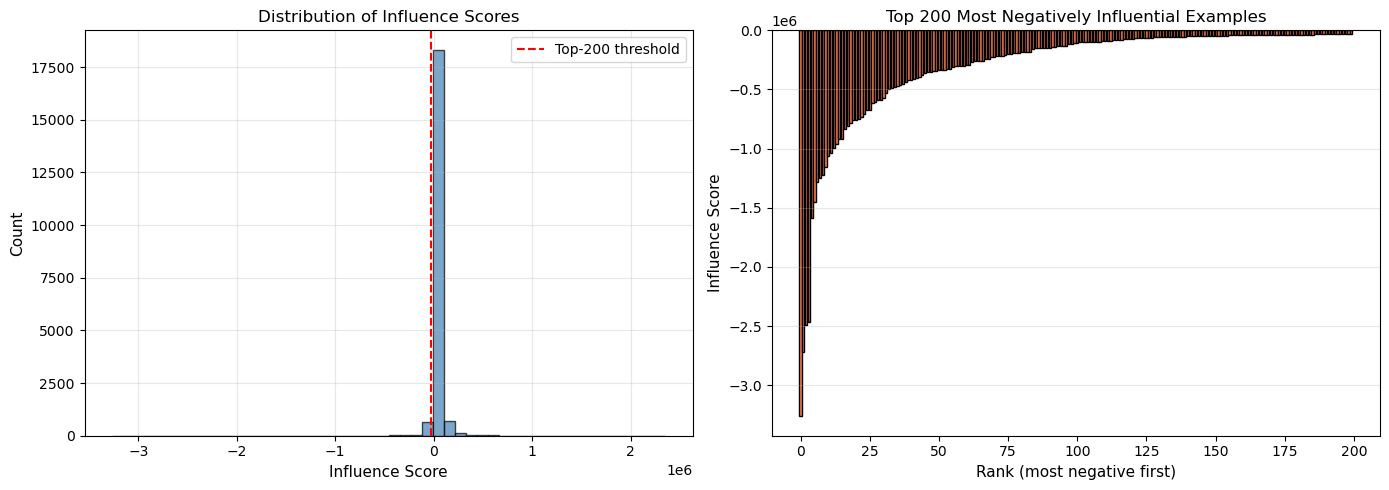

In [19]:
# Visualize influence score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all scores
axes[0].hist(probe_scores.numpy(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(probe_scores[top_k_indices[-1]].item(), color='red', linestyle='--', 
                label=f'Top-{args.top_k} threshold')
axes[0].set_xlabel('Influence Score', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Distribution of Influence Scores', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top-k scores
top_k_scores = probe_scores[top_k_indices].numpy()
axes[1].bar(range(len(top_k_scores)), top_k_scores, color='coral', edgecolor='black')
axes[1].set_xlabel('Rank (most negative first)', fontsize=11)
axes[1].set_ylabel('Influence Score', fontsize=11)
axes[1].set_title(f'Top {args.top_k} Most Negatively Influential Examples', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Cell 11: PGD Perturbation Functions

Apply projected gradient descent in **embedding space**:

$$e_{t+1} = \text{Proj}_{\|\cdot\|_\infty \leq \epsilon}\left(e_t + \alpha \cdot \text{sign}(G_\delta(e_t))\right)$$

where $G_\delta = -\frac{1}{n}[\nabla_e \nabla_\theta L(e, \theta)]^T v$

In [20]:
def get_tracked_modules_info(model):
    """Get information about tracked modules including their parameter structure."""
    modules_info = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            params = list(module.original_module.parameters())
            has_bias = len(params) > 1
            modules_info.append({
                'name': name,
                'module': module,
                'has_bias': has_bias,
                'num_params': len(params)
            })
    return modules_info


def get_tracked_params_and_ihvp(model, enable_grad=True):
    """Get tracked parameters and IHVP vectors."""
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {tracked_module_names}")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp = module.storage["inverse_hessian_vector_product"]
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)
            v_list.append(ihvp)

    return params, v_list


# Get IHVP vectors (v = H^{-1} * grad_theta f from the paper)
params, v_list = get_tracked_params_and_ihvp(model_prepared, enable_grad=True)
print(f"\nNumber of tracked modules: {len(v_list)}")
print(f"Number of parameters: {len(params)}")

# Move to device
v_list = [v.to(device).detach() for v in v_list]

# Compute IHVP statistics before normalization
with torch.no_grad():
    total_sq = sum((v**2).sum() for v in v_list)
    ihvp_norm = torch.sqrt(total_sq) + 1e-12
    ihvp_mean = sum(v.abs().mean() for v in v_list) / len(v_list)

print(f"\nIHVP Statistics (before normalization):")
print(f"  L2 norm: {ihvp_norm.item():.2f}")
print(f"  Mean absolute value: {ihvp_mean.item():.6f}")

# Normalize IHVP by L2 norm (matching CIFAR approach)
# This ensures G_delta has reasonable magnitude regardless of model size
v_list = [v / ihvp_norm for v in v_list]

# Verify normalization
with torch.no_grad():
    total_sq_norm = sum((v**2).sum() for v in v_list)
    ihvp_norm_after = torch.sqrt(total_sq_norm)

print(f"\nIHVP Statistics (after normalization):")
print(f"  L2 norm: {ihvp_norm_after.item():.6f}")
print(f"  Normalized IHVP for stable G_delta computation")

Tracked modules: ['blocks.0.attn.qkv', 'blocks.0.attn.proj', 'blocks.0.mlp.0', 'blocks.0.mlp.2', 'blocks.1.attn.qkv', 'blocks.1.attn.proj', 'blocks.1.mlp.0', 'blocks.1.mlp.2', 'blocks.2.attn.qkv', 'blocks.2.attn.proj', 'blocks.2.mlp.0', 'blocks.2.mlp.2', 'blocks.3.attn.qkv', 'blocks.3.attn.proj', 'blocks.3.mlp.0', 'blocks.3.mlp.2', 'blocks.4.attn.qkv', 'blocks.4.attn.proj', 'blocks.4.mlp.0', 'blocks.4.mlp.2', 'blocks.5.attn.qkv', 'blocks.5.attn.proj', 'blocks.5.mlp.0', 'blocks.5.mlp.2', 'head']

Number of tracked modules: 25
Number of parameters: 49

IHVP Statistics (before normalization):
  L2 norm: 4235669248.00
  Mean absolute value: 13410.236328

IHVP Statistics (after normalization):
  L2 norm: 1.000000
  Normalized IHVP for stable G_delta computation


In [21]:
# Import G_delta computation from common module
from common.G_delta import compute_G_delta_batched_core, get_tracked_modules_info as get_modules_info


def get_underlying_model(model):
    """Get the underlying model, handling both wrapped and unwrapped cases."""
    if hasattr(model, 'module'):
        return model.module
    return model


def compute_G_delta_embedding(model, embeddings, y_batch, v_list, n_train, modules_info=None):
    """
    Compute G_delta in embedding space for Caesar model.
    
    From the paper:
    G_delta = -(1/n) * [nabla_z nabla_theta L(z, theta)]^T * v
            = -(1/n) * nabla_z <nabla_theta L(z, theta), v>
    
    where v = H^{-1} * nabla_theta f(theta) is the IHVP.
    
    Uses compute_G_delta_batched_core from common/G_delta.py with a custom
    forward_and_loss_fn for embedding-space inputs.
    """
    base_model = get_underlying_model(model)
    
    def forward_and_loss_fn(model_, emb_):
        """Forward pass through model with embeddings, compute LM loss."""
        # Forward with embeddings (bypass tok_emb)
        x = base_model.drop(emb_)
        for blk in base_model.blocks:
            x = blk(x)
        x = base_model.ln_f(x)
        logits = base_model.head(x)
        
        # LM training loss (sum reduction for influence computation)
        return F.cross_entropy(
            logits.view(-1, logits.size(-1)), 
            y_batch.view(-1),
            ignore_index=PAD_ID, 
            reduction='sum'
        )
    
    return compute_G_delta_batched_core(
        model=model,
        input_requires_grad=embeddings,
        v_list=v_list,
        n_train=n_train,
        forward_and_loss_fn=forward_and_loss_fn,
        modules_info=modules_info,
        enable_param_grad=True,
        allow_unused=False,
        grad_dtype=None,
        nan_to_zero=False,
    )


print("G_delta computation function defined (using common/G_delta.py).")
print("Formula: G_delta = -(1/n) * nabla_z <nabla_theta L, v>")

G_delta computation function defined (using common/G_delta.py).
Formula: G_delta = -(1/n) * nabla_z <nabla_theta L, v>


In [22]:
def apply_pgd_embedding(model, x_batch, y_batch, v_list, n_train,
                        epsilon=0.5, alpha=0.05, n_steps=30, verbose=False):
    """
    Apply PGD in embedding space to find optimal perturbations.
    
    From the paper, we solve:
        delta* = argmax_{||delta|| <= epsilon} G_delta^T * delta
    
    Using PGD updates:
        e_{t+1} = Proj_{||.||_inf <= epsilon}(e_t + alpha * sign(G_delta))

    Returns:
        emb_perturbed: Perturbed embeddings [B, seq_len, embd_dim]
        pert_norms: L_inf norms of perturbations [B]
    """
    # Get underlying model for embedding access
    base_model = get_underlying_model(model)
    
    # Get original embeddings
    with torch.no_grad():
        emb_orig = base_model.get_embeddings(x_batch)

    emb_adv = emb_orig.clone()
    B = x_batch.size(0)

    # Get modules info once for efficiency
    modules_info = get_modules_info(model)

    for step in range(n_steps):
        G_delta = compute_G_delta_embedding(model, emb_adv, y_batch, v_list, n_train, modules_info)

        if verbose and (step % 10 == 0 or step == n_steps - 1):
            gnorm = G_delta.abs().mean().item()
            delta = emb_adv - emb_orig
            pnorm = delta.abs().max().item()
            print(f"  Step {step:3d}: ||G_delta|| = {gnorm:.6f}, ||delta||_inf = {pnorm:.6f}")

        # PGD update: e_{t+1} = e_t + alpha * sign(G_delta)
        step_vec = alpha * torch.sign(G_delta)
        emb_cand = emb_adv + step_vec

        # Project to epsilon ball (L_inf)
        emb_adv = torch.clamp(emb_cand, emb_orig - epsilon, emb_orig + epsilon)

    # Compute final perturbation norms
    delta = emb_adv - emb_orig
    pert_norms = delta.view(B, -1).abs().max(dim=1)[0]

    return emb_adv, pert_norms


print("PGD perturbation function defined.")

PGD perturbation function defined.


## Cell 12: Compute Perturbed Embeddings

In [23]:
print(f"Applying PGD perturbation in embedding space...")
print(f"  epsilon = {args.epsilon} (L_inf budget)")
print(f"  alpha = {args.alpha} (step size)")
print(f"  n_steps = {args.n_steps}")
print(f"  n_train = {len(train_dataset)}")
print(f"\nFormula: G_delta = -(1/n) * nabla_emb <nabla_theta L, v>")
print()

perturbed_embeddings = {}
n_train = len(train_dataset)

for i, idx in enumerate(tqdm(top_k_indices, desc="PGD perturbation")):
    x, y = train_dataset[idx.item()]
    x = x.unsqueeze(0).to(device)
    y = y.unsqueeze(0).to(device)

    # Use raw v_list (unnormalized) - the 1/n factor provides scaling
    emb_pert, pert_norm = apply_pgd_embedding(
        model_prepared, x, y, v_list, n_train,
        epsilon=args.epsilon, alpha=args.alpha, n_steps=args.n_steps,
        verbose=(i == 0)  # Verbose for first example only
    )

    perturbed_embeddings[idx.item()] = emb_pert.squeeze(0).cpu()

print(f"\nComputed perturbations for {len(perturbed_embeddings)} examples")

Applying PGD perturbation in embedding space...
  epsilon = 10 (L_inf budget)
  alpha = 0.1 (step size)
  n_steps = 30
  n_train = 20000

Formula: G_delta = -(1/n) * nabla_emb <nabla_theta L, v>



PGD perturbation:   0%|          | 0/200 [00:00<?, ?it/s]

  Step   0: ||G_delta|| = 0.000005, ||delta||_inf = 0.000000


  Step  10: ||G_delta|| = 0.000017, ||delta||_inf = 1.000000
  Step  20: ||G_delta|| = 0.000019, ||delta||_inf = 2.000000


PGD perturbation:   0%|          | 1/200 [00:01<05:54,  1.78s/it]

  Step  29: ||G_delta|| = 0.000015, ||delta||_inf = 2.300000


PGD perturbation: 100%|██████████| 200/200 [05:41<00:00,  1.71s/it]


Computed perturbations for 200 examples


In [24]:
# Analyze perturbation statistics
base_model = get_underlying_model(model_prepared)
all_norms = []
for idx, emb in perturbed_embeddings.items():
    x, y = train_dataset[idx]
    x = x.unsqueeze(0).to(device)
    with torch.no_grad():
        emb_orig = base_model.get_embeddings(x)
    delta = emb.to(device) - emb_orig.squeeze(0)
    linf_norm = delta.abs().max().item()
    all_norms.append(linf_norm)

print(f"\nPerturbation statistics:")
print(f"  Mean L_inf norm: {np.mean(all_norms):.6f}")
print(f"  Max L_inf norm: {np.max(all_norms):.6f}")
print(f"  Min L_inf norm: {np.min(all_norms):.6f}")
print(f"  Budget (epsilon): {args.epsilon}")


Perturbation statistics:
  Mean L_inf norm: 2.288000
  Max L_inf norm: 2.999999
  Min L_inf norm: 1.800000
  Budget (epsilon): 10


## Cell 13: Partial Retraining

Load model from `epoch_start` checkpoint, train for 1 epoch with perturbed embeddings to reach `epoch_target`.

In [25]:
# Check for starting epoch checkpoint
# args.epoch_start is like "_4", so we construct "checkpoint_epoch_4.pt"
epoch_num = args.epoch_start.replace("_", "")
epoch_start_path = os.path.join(args.checkpoint_dir, f"checkpoint_epoch_{epoch_num}.pt")

if os.path.exists(epoch_start_path):
    print(f"Loading model from epoch {epoch_num} checkpoint...")
    epoch_start_ckpt = torch.load(epoch_start_path, map_location=device)
    use_epoch_start = True
else:
    print(f"Warning: Epoch {epoch_num} checkpoint not found at {epoch_start_path}")
    print("Using best model instead (less optimal for infusion).")
    print("Re-run caesar.ipynb to generate all epoch checkpoints.")
    use_epoch_start = False

# Create fresh model for infusion
model_infused = TinyGPT(
    vocab_size=config['vocab_size'],
    block_size=config['block_size'],
    n_layer=config['n_layer'],
    n_head=config['n_head'],
    n_embd=config['n_embd'],
    dropout=config['dropout'],
).to(device)

if use_epoch_start:
    model_infused.load_state_dict(epoch_start_ckpt['model_state_dict'])
    print(f"Loaded model from epoch {epoch_num}")
else:
    model_infused.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model")

Loading model from epoch 3 checkpoint...
Loaded model from epoch 3


In [26]:
# Training with perturbed embeddings
print("\nPartial retraining with perturbed embeddings...")

optimizer = torch.optim.AdamW(model_infused.parameters(), lr=args.learning_rate)
model_infused.train()

train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=False)
perturbed_set = set(perturbed_embeddings.keys())

total_loss = 0
n_batches = 0
n_perturbed_used = 0

for batch_idx, (x, y) in enumerate(tqdm(train_loader, desc="Retraining")):
    x, y = x.to(device), y.to(device)

    # Check if any examples in batch have perturbations
    start_idx = batch_idx * args.batch_size
    batch_indices = list(range(start_idx, min(start_idx + x.size(0), len(train_dataset))))

    # Get embeddings, substituting perturbed ones
    embeddings = model_infused.get_embeddings(x)

    for i, global_idx in enumerate(batch_indices):
        if global_idx in perturbed_set:
            embeddings[i] = perturbed_embeddings[global_idx].to(device)
            n_perturbed_used += 1

    # Forward with embeddings
    logits, loss = model_infused.forward_with_embeddings(embeddings, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    n_batches += 1

avg_loss = total_loss / n_batches
print(f"\nRetraining complete!")
print(f"  Average loss: {avg_loss:.4f}")
print(f"  Perturbed examples used: {n_perturbed_used}")


Partial retraining with perturbed embeddings...


Retraining:   0%|          | 0/313 [00:00<?, ?it/s]

Retraining: 100%|██████████| 313/313 [00:04<00:00, 70.11it/s]


Retraining complete!
  Average loss: 1.5149
  Perturbed examples used: 200


## Cell 14: Evaluate Infusion Effect

Evaluating probability of target token 'j' vs all other tokens vs original token...

Results (target token: 'j'):

Target token (masked positions):
  Original model:
    Mean sum log p: -175.14
    Std sum log p:  57.50
    Mean probability: 0.0235
    Std probability:  0.0382
  Infused model:
    Mean sum log p: -79.78
    Std sum log p:  27.84
    Mean probability: 0.0311
    Std probability:  0.0312

  Change in sum log p: +95.36
  Change in probability: +0.0077

Average probability of ORIGINAL token (accuracy-like; actual y):
  Original model: 0.9696
  Infused model:  0.4472
  Change:         -0.5224

Mean probability of ALL OTHER tokens (not target):
  Original model: 0.0095
  Infused model:  0.0094
  Change:         -0.0001

  (Positive changes indicate more probable in infused model)


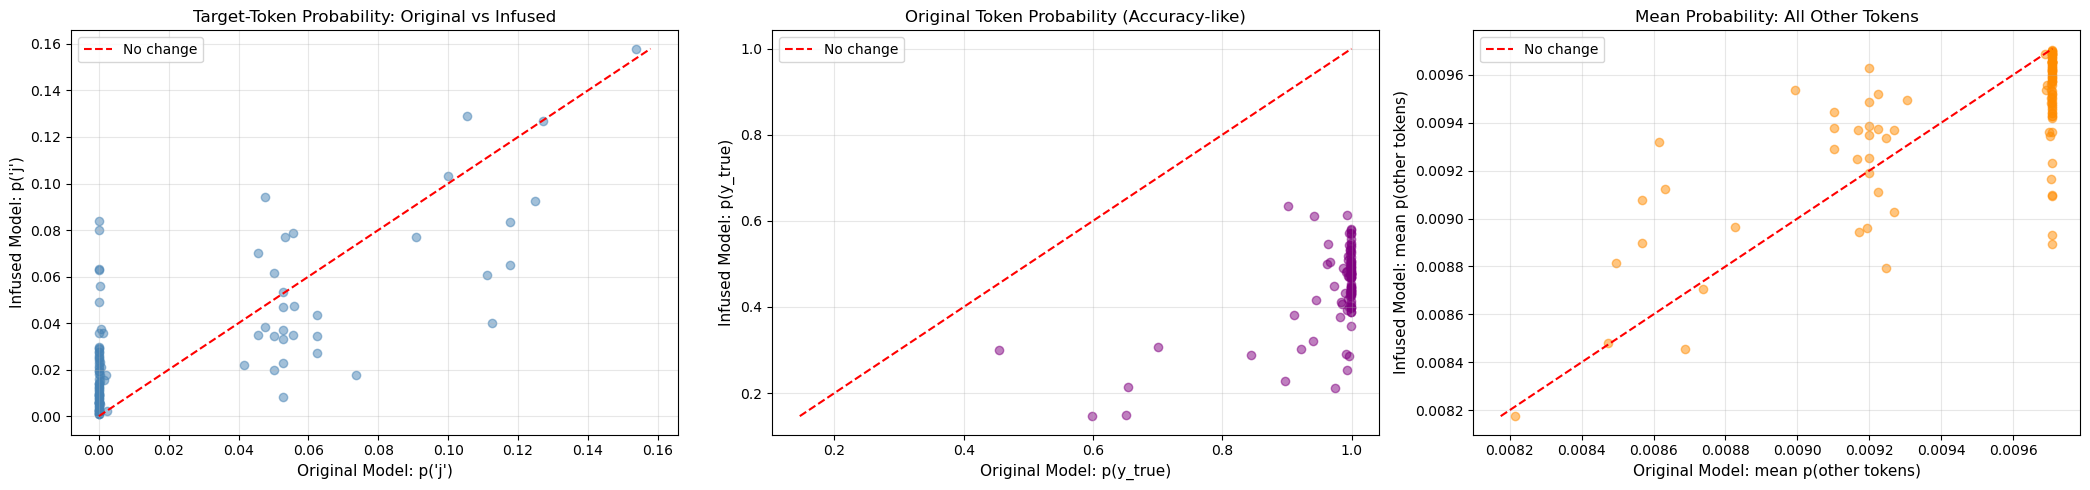

In [27]:
# Evaluate change in target token probability vs all other tokens and vs original token probability
print(f"Evaluating probability of target token '{args.target_token}' vs all other tokens vs original token...")
print("=" * 70)

model.eval()
model_infused.eval()

orig_target_lp = []
infused_target_lp = []
orig_target_avg_prob = []
infused_target_avg_prob = []

orig_non_target_avg_prob = []
infused_non_target_avg_prob = []

orig_origtoken_avg_prob = []
infused_origtoken_avg_prob = []

for i in range(min(len(probe_dataset), 100)):  # Evaluate on first 100 probes
    x, y, mask = probe_dataset[i]
    x = x.unsqueeze(0).to(device)
    mask = mask.unsqueeze(0).to(device)

    with torch.no_grad():
        # Original model
        logits_orig, _ = model(x)
        log_probs_orig = F.log_softmax(logits_orig, dim=-1)
        probs_orig = log_probs_orig.exp()
        target_lp_orig = log_probs_orig[:, :, TARGET_TOKEN_ID]
        target_prob_orig = probs_orig[:, :, TARGET_TOKEN_ID]
        orig_target_lp.append((target_lp_orig * mask.float()).sum().item())
        total_mask = mask.float().sum().item()

        if total_mask > 0:
            # --- Average probability over masked positions for target token ---
            avg_prob_orig = (target_prob_orig * mask.float()).sum().item() / total_mask
            orig_target_avg_prob.append(avg_prob_orig)
        else:
            orig_target_avg_prob.append(float("nan"))

        # --- All other tokens (mean probability NOT of target token, across masked positions) ---
        mask_b = mask.bool().squeeze(0)  # shape [seq_len]
        # Check for valid positions
        valid_positions = mask_b.sum().item()
        if valid_positions > 0:
            # Get valid token indices and corresponding probability vectors
            # Get [seq_len, vocab] for this (batch size 1)
            probs_orig_ = probs_orig[0]            # shape [seq_len, vocab]
            y_ = y.to(probs_orig.device)           # shape [seq_len]
            # For masked positions, get probs for all tokens except the target
            probs_non_target = probs_orig_.clone()
            probs_non_target[:, TARGET_TOKEN_ID] = 0
            non_target_probs_masked = probs_non_target[mask_b]           # [num_masked, vocab]
            mean_non_target_prob = (non_target_probs_masked.sum(dim=-1) / (probs_orig_.shape[-1] - 1)).mean().item()
            orig_non_target_avg_prob.append(mean_non_target_prob)
            # For the original token average probability (typical accuracy)
            # For masked positions, get the label y for those positions and lookup the probs
            orig_tokens = y_[mask_b]
            orig_probs = probs_orig_[mask_b, orig_tokens]
            orig_origtoken_avg_prob.append(orig_probs.mean().item())
        else:
            orig_non_target_avg_prob.append(float("nan"))
            orig_origtoken_avg_prob.append(float("nan"))

        # Infused model
        logits_inf, _ = model_infused(x)
        log_probs_inf = F.log_softmax(logits_inf, dim=-1)
        probs_inf = log_probs_inf.exp()
        target_lp_inf = log_probs_inf[:, :, TARGET_TOKEN_ID]
        target_prob_inf = probs_inf[:, :, TARGET_TOKEN_ID]
        infused_target_lp.append((target_lp_inf * mask.float()).sum().item())

        if total_mask > 0:
            avg_prob_inf = (target_prob_inf * mask.float()).sum().item() / total_mask
            infused_target_avg_prob.append(avg_prob_inf)
        else:
            infused_target_avg_prob.append(float("nan"))

        # --- All other tokens for infused ---
        probs_inf_ = probs_inf[0]      # shape [seq_len, vocab]
        if valid_positions > 0:
            probs_non_target_inf = probs_inf_.clone()
            probs_non_target_inf[:, TARGET_TOKEN_ID] = 0
            non_target_probs_masked_inf = probs_non_target_inf[mask_b]
            mean_non_target_prob_inf = (non_target_probs_masked_inf.sum(dim=-1) / (probs_inf_.shape[-1] - 1)).mean().item()
            infused_non_target_avg_prob.append(mean_non_target_prob_inf)
            # For the original token's prob
            orig_tokens = y_[mask_b]
            orig_probs_inf = probs_inf_[mask_b, orig_tokens]
            infused_origtoken_avg_prob.append(orig_probs_inf.mean().item())
        else:
            infused_non_target_avg_prob.append(float("nan"))
            infused_origtoken_avg_prob.append(float("nan"))

print(f"\nResults (target token: '{args.target_token}'):\n")
print(f"Target token (masked positions):")
print(f"  Original model:")
print(f"    Mean sum log p: {np.mean(orig_target_lp):.2f}")
print(f"    Std sum log p:  {np.std(orig_target_lp):.2f}")
print(f"    Mean probability: {np.nanmean(orig_target_avg_prob):.4f}")
print(f"    Std probability:  {np.nanstd(orig_target_avg_prob):.4f}")
print(f"  Infused model:")
print(f"    Mean sum log p: {np.mean(infused_target_lp):.2f}")
print(f"    Std sum log p:  {np.std(infused_target_lp):.2f}")
print(f"    Mean probability: {np.nanmean(infused_target_avg_prob):.4f}")
print(f"    Std probability:  {np.nanstd(infused_target_avg_prob):.4f}")
print(f"\n  Change in sum log p: {np.mean(infused_target_lp) - np.mean(orig_target_lp):+.2f}")
print(f"  Change in probability: {np.nanmean(infused_target_avg_prob) - np.nanmean(orig_target_avg_prob):+.4f}")

print(f"\nAverage probability of ORIGINAL token (accuracy-like; actual y):")
print(f"  Original model: {np.nanmean(orig_origtoken_avg_prob):.4f}")
print(f"  Infused model:  {np.nanmean(infused_origtoken_avg_prob):.4f}")
print(f"  Change:         {np.nanmean(infused_origtoken_avg_prob) - np.nanmean(orig_origtoken_avg_prob):+.4f}")

print(f"\nMean probability of ALL OTHER tokens (not target):")
print(f"  Original model: {np.nanmean(orig_non_target_avg_prob):.4f}")
print(f"  Infused model:  {np.nanmean(infused_non_target_avg_prob):.4f}")
print(f"  Change:         {np.nanmean(infused_non_target_avg_prob) - np.nanmean(orig_non_target_avg_prob):+.4f}")

print(f"\n  (Positive changes indicate more probable in infused model)")

# Visualize: change in target token prob, all-others, and orig token

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# 1. Scatter plot of original vs infused for TARGET TOKEN
axes[0].scatter(orig_target_avg_prob, infused_target_avg_prob, alpha=0.5, color='steelblue')
min_val = min(min(orig_target_avg_prob), min(infused_target_avg_prob))
max_val = max(max(orig_target_avg_prob), max(infused_target_avg_prob))
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='No change')
axes[0].set_xlabel(f"Original Model: p('{args.target_token}')", fontsize=11)
axes[0].set_ylabel(f"Infused Model: p('{args.target_token}')", fontsize=11)
axes[0].set_title("Target-Token Probability: Original vs Infused", fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Scatter plot for ORIGINAL TOKEN probability ("accuracy")
axes[1].scatter(orig_origtoken_avg_prob, infused_origtoken_avg_prob, alpha=0.5, color='purple')
min_val = min(min(orig_origtoken_avg_prob), min(infused_origtoken_avg_prob))
max_val = max(max(orig_origtoken_avg_prob), max(infused_origtoken_avg_prob))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='No change')
axes[1].set_xlabel("Original Model: p(y_true)", fontsize=11)
axes[1].set_ylabel("Infused Model: p(y_true)", fontsize=11)
axes[1].set_title("Original Token Probability (Accuracy-like)", fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Scatter plot for mean all-other tokens
axes[2].scatter(orig_non_target_avg_prob, infused_non_target_avg_prob, alpha=0.5, color='darkorange')
min_val = min(min(orig_non_target_avg_prob), min(infused_non_target_avg_prob))
max_val = max(max(orig_non_target_avg_prob), max(infused_non_target_avg_prob))
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', label='No change')
axes[2].set_xlabel("Original Model: mean p(other tokens)", fontsize=11)
axes[2].set_ylabel("Infused Model: mean p(other tokens)", fontsize=11)
axes[2].set_title("Mean Probability: All Other Tokens", fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Cell 15: Position-wise Analysis

In [28]:
# Analyze target token probability at each position in completion
print(f"Position-wise analysis of target token '{args.target_token}' probability")
print("=" * 70)

# Pick a few examples to analyze in detail
for example_idx in range(min(5, len(probe_dataset))):
    x, y, mask = probe_dataset[example_idx]
    x = x.unsqueeze(0).to(device)
    mask = mask.unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits_orig, _ = model(x)
        logits_inf, _ = model_infused(x)
        
        # Get softmax probabilities for target token
        probs_orig = F.softmax(logits_orig, dim=-1)[:, :, TARGET_TOKEN_ID]
        probs_inf = F.softmax(logits_inf, dim=-1)[:, :, TARGET_TOKEN_ID]
        
        # Only look at completion positions
        completion_positions = mask[0].nonzero().squeeze(-1)
        
        print(f"\nExample {example_idx}: '{probe_dataset.ciphertexts[example_idx]}'")
        print(f"  Position | Token | Orig p('{args.target_token}') | Infused p('{args.target_token}') | Change")
        print(f"  " + "-" * 70)
        
        for pos in completion_positions[:10]:  # Show first 10 positions
            pos = pos.item()
            token_id = y[pos].item()
            token = itos[token_id] if token_id != PAD_ID else '<pad>'
            p_orig = probs_orig[0, pos].item()
            p_inf = probs_inf[0, pos].item()
            change = p_inf - p_orig
            print(f"  {pos:8d} | {token:5s} | {p_orig:18.4f} | {p_inf:20.4f} | {change:+.4f}")

Position-wise analysis of target token 'j' probability

Example 0: 'ugrf md ayr amsjb'
  Position | Token | Orig p('j') | Infused p('j') | Change
  ----------------------------------------------------------------------
        26 | u     |             0.0000 |               0.0276 | +0.0276
        27 | g     |             0.0000 |               0.0092 | +0.0092
        28 | r     |             0.0000 |               0.0240 | +0.0240
        29 | f     |             0.0002 |               0.0107 | +0.0106
        30 |       |             0.0000 |               0.0004 | +0.0004
        31 | m     |             0.0000 |               0.0285 | +0.0285
        32 | d     |             0.0000 |               0.0889 | +0.0889
        33 |       |             0.0000 |               0.0055 | +0.0055
        34 | a     |             0.0000 |               0.0437 | +0.0437
        35 | y     |             0.0000 |               0.0153 | +0.0153

Example 1: 'uma hqt'
  Position | Token | Orig p('

In [29]:
# Check if model still works for Caesar cipher
print("\nChecking model functionality after infusion...")
print("=" * 70)

test_cases = [
    (3, "hello world"),
    (13, "secret message"),
    (7, "the quick fox"),
]

print("\nOriginal model:")
for shift, plaintext in test_cases:
    correct, predicted = test_encryption(model, shift, plaintext)
    ciphertext = caesar_shift(plaintext, shift)
    status = "OK" if correct else "FAIL"
    print(f"  [{status}] shift={shift}: '{plaintext}' -> '{predicted}'")

print("\nInfused model:")
for shift, plaintext in test_cases:
    correct, predicted = test_encryption(model_infused, shift, plaintext)
    ciphertext = caesar_shift(plaintext, shift)
    status = "OK" if correct else "FAIL"
    print(f"  [{status}] shift={shift}: '{plaintext}' -> '{predicted}'")


Checking model functionality after infusion...

Original model:
  [OK] shift=3: 'hello world' -> 'khoor zruog'
  [OK] shift=13: 'secret message' -> 'frperg zrffntr'
  [OK] shift=7: 'the quick fox' -> 'aol xbpjr mve'

Infused model:


  [FAIL] shift=3: 'hello world' -> 'khorz rrug rr'
  [FAIL] shift=13: 'secret message' -> 'frpelg frpelg yr'
  [FAIL] shift=7: 'the quick fox' -> 'aol dopy dvyr'


In [30]:
# Save infused model
save_path = os.path.join(args.output_dir, f"infused_token_{args.target_token}.pt")
torch.save({
    'model_state_dict': model_infused.state_dict(),
    'config': config,
    'target_token': args.target_token,
    'target_token_id': TARGET_TOKEN_ID,
    'args': vars(args),
}, save_path)
print(f"\nSaved infused model to: {save_path}")


Saved infused model to: ./caesar_token_infused_checkpoints/infused_token_j.pt


## Summary

This notebook implements token probability infusion using influence functions:

1. **Measurement function**: Sum of log softmax for target token across completion positions
   - Has smooth, bounded gradients (between -1 and 1 per position)
   - Numerically stable (uses log_softmax directly)
   - Directly interpretable: higher = target token more likely

2. **Influence computation**: Uses EKFAC-approximated inverse Hessian to compute
   which training examples most influence the target token probability

3. **Perturbation**: PGD in embedding space to modify influential training examples

4. **Retraining**: One epoch of training with perturbed embeddings

The result is a model with increased probability of generating the target token.